
# 24ADI204 – Data Science and Visualization
## Exploratory Data Analysis (EDA) and Data Visualization

**Name:** Arunvignesh R S

**Roll Number:** 25BAD012

**Dataset:** Netflix Movies and TV Shows  
**Source:** Kaggle – Shivam Bansal, *Netflix Movies and TV Shows*

This notebook performs Exploratory Data Analysis (EDA) on the Netflix titles dataset and contains **30 meaningful visualizations** using different chart types.


## 1. Import Libraries and Load the Kaggle Dataset

In [ ]:

# Install KaggleHub if required
!pip -q install kagglehub

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Download the public Kaggle dataset
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Dataset downloaded to:", path)

# Locate netflix_titles.csv
csv_path = os.path.join(path, "netflix_titles.csv")
df = pd.read_csv(csv_path)

df.head()


Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Dataset Overview

In [ ]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


## Plot 1 – Distribution of Content Type
Shows the proportion of Movies and TV Shows available in the dataset.

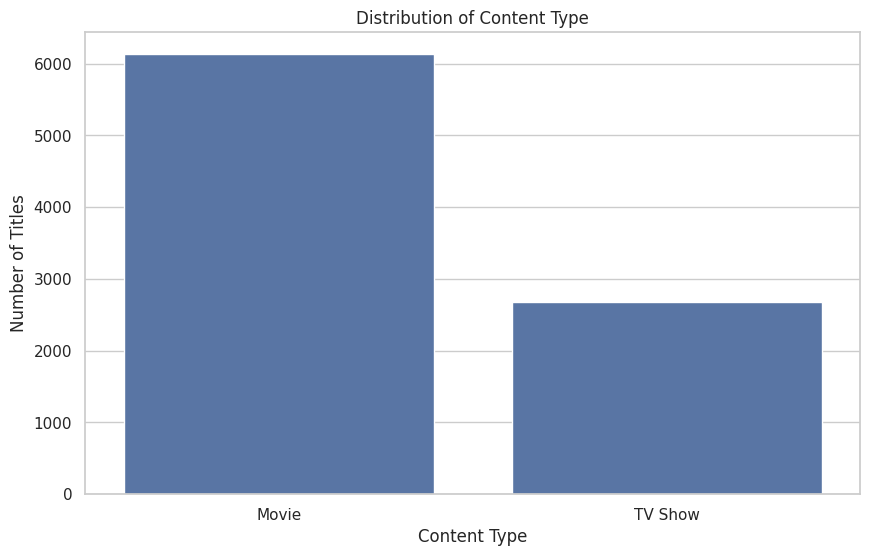

In [ ]:

plt.figure()
sns.countplot(data=df, x="type")
plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()


## Plot 2 – Content Type Pie Chart
Shows the percentage share of Movies and TV Shows.

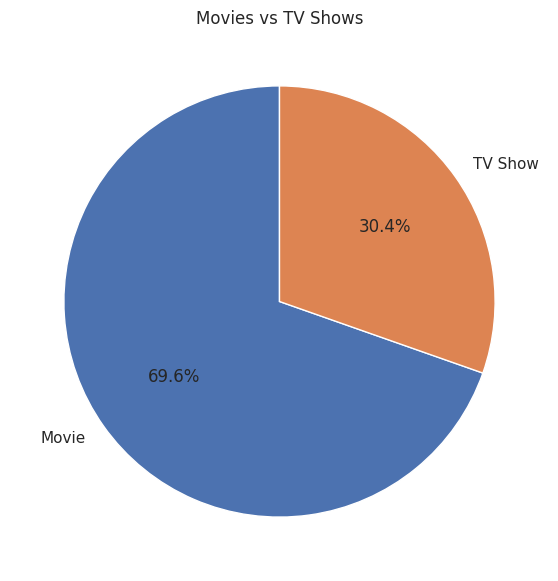

In [ ]:

type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Movies vs TV Shows")
plt.show()


## Plot 3 – Titles Released by Year
Shows how the number of titles released has changed over the years.

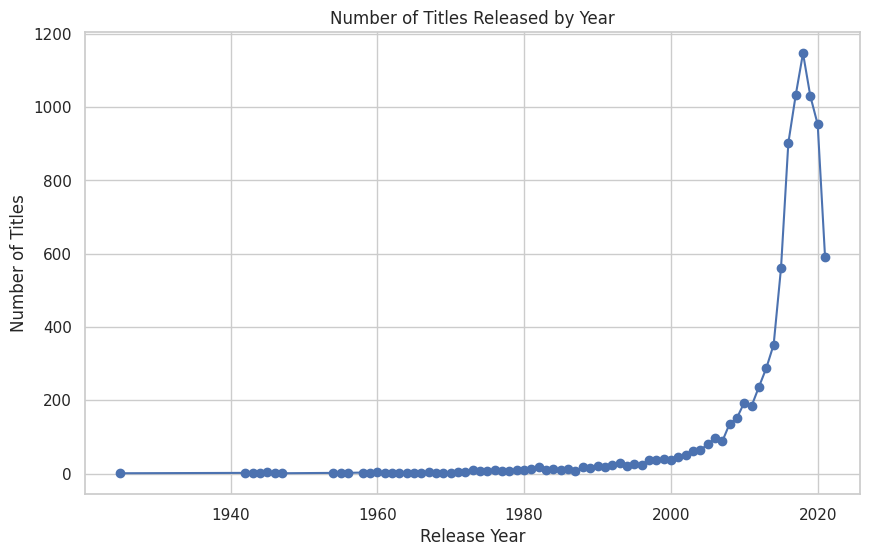

In [ ]:

release_year_counts = df["release_year"].value_counts().sort_index()

plt.figure()
plt.plot(release_year_counts.index, release_year_counts.values, marker="o")
plt.title("Number of Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


## Plot 4 – Movies and TV Shows Released by Year
Compares the yearly release patterns of Movies and TV Shows.

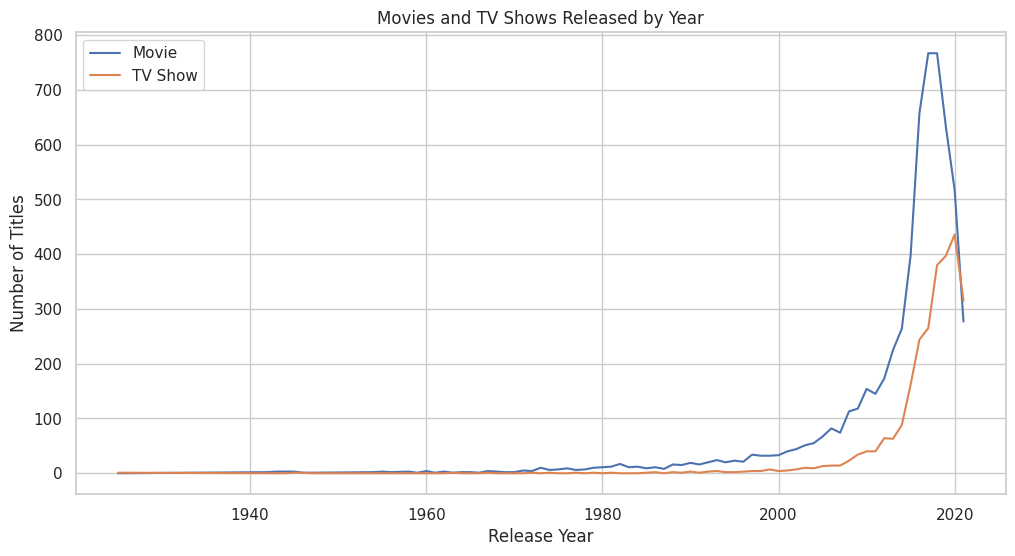

In [ ]:

year_type = df.groupby(["release_year", "type"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.plot(year_type.index, year_type.get("Movie", 0), label="Movie")
plt.plot(year_type.index, year_type.get("TV Show", 0), label="TV Show")
plt.title("Movies and TV Shows Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()


## Plot 5 – Top 15 Countries by Number of Titles
Identifies the countries that contribute the largest number of titles.

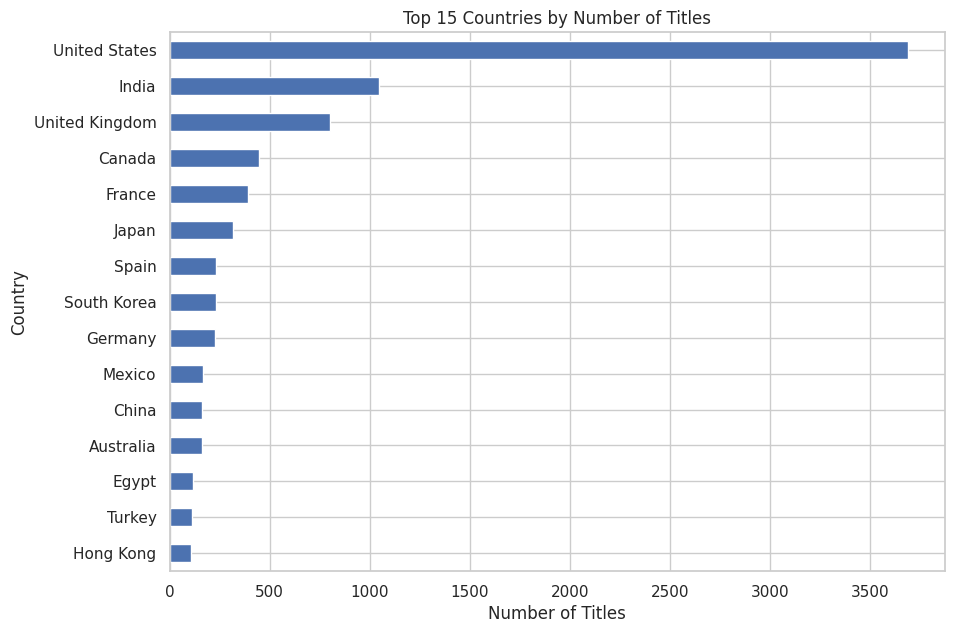

In [ ]:

country_counts = (
    df["country"].dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
country_counts.plot(kind="barh")
plt.title("Top 15 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


## Plot 6 – Top 15 Genres
Shows the most frequently occurring genres/categories in the Netflix catalogue.

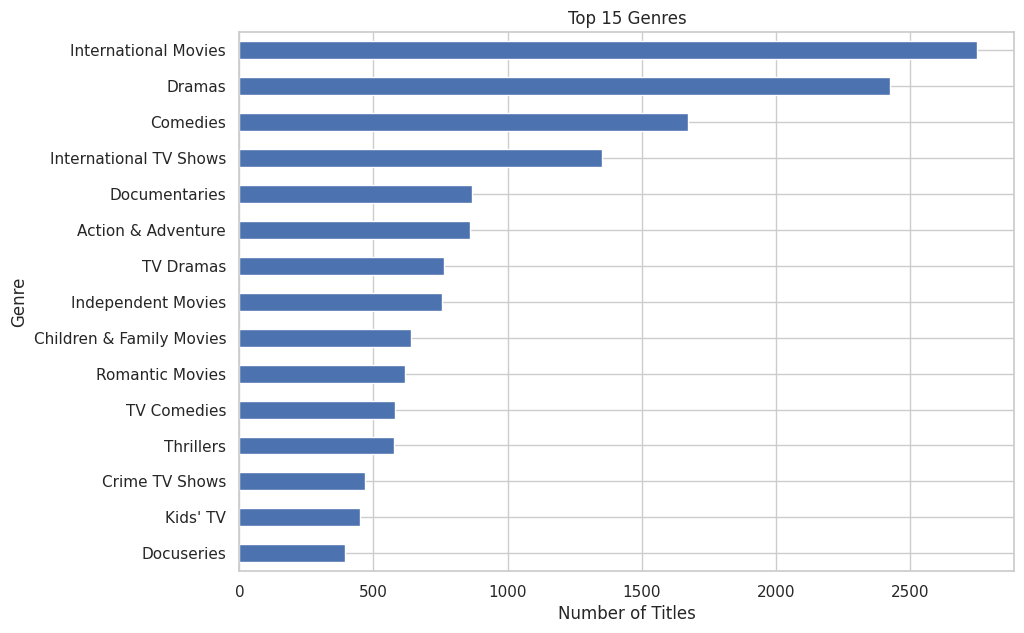

In [ ]:

genre_counts = (
    df["listed_in"].dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
genre_counts.plot(kind="barh")
plt.title("Top 15 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()


## Plot 7 – Top 15 Ratings
Shows the distribution of Netflix content across different maturity ratings.

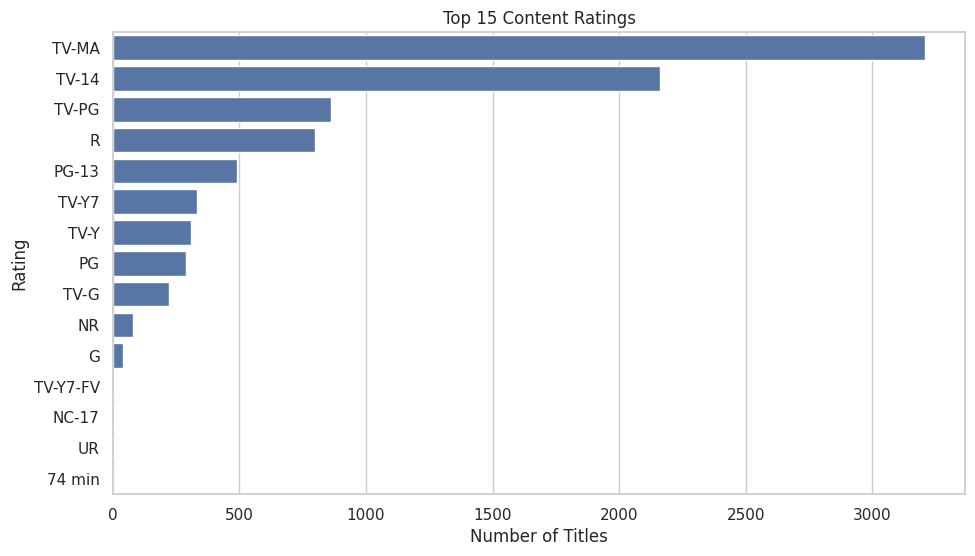

In [ ]:

rating_counts = df["rating"].value_counts().head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=rating_counts.values, y=rating_counts.index)
plt.title("Top 15 Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()


## Plot 8 – Movie Duration Distribution
Shows the distribution of movie running times in minutes.

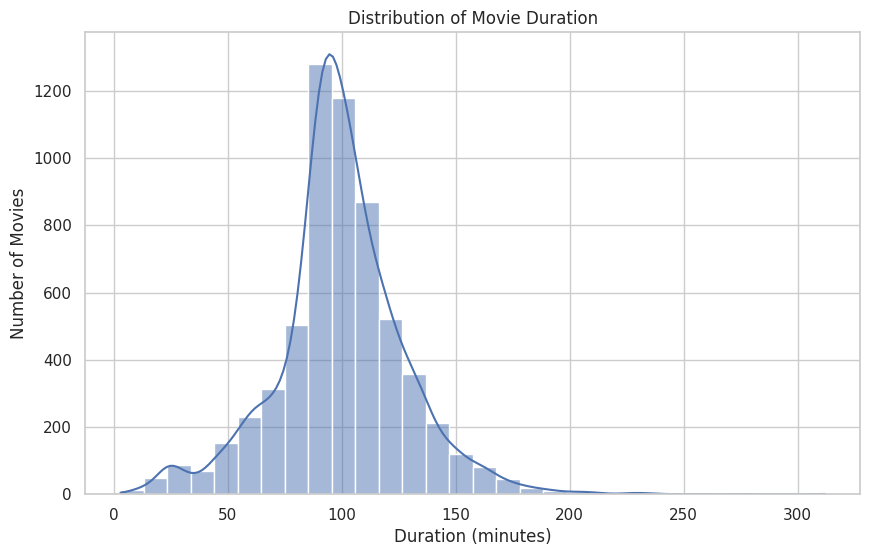

In [ ]:

movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = pd.to_numeric(
    movies["duration"].str.extract(r"(\d+)")[0], errors="coerce"
)

plt.figure()
sns.histplot(movies["duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()


## Plot 9 – TV Show Seasons Distribution
Shows how many seasons TV Shows typically have.

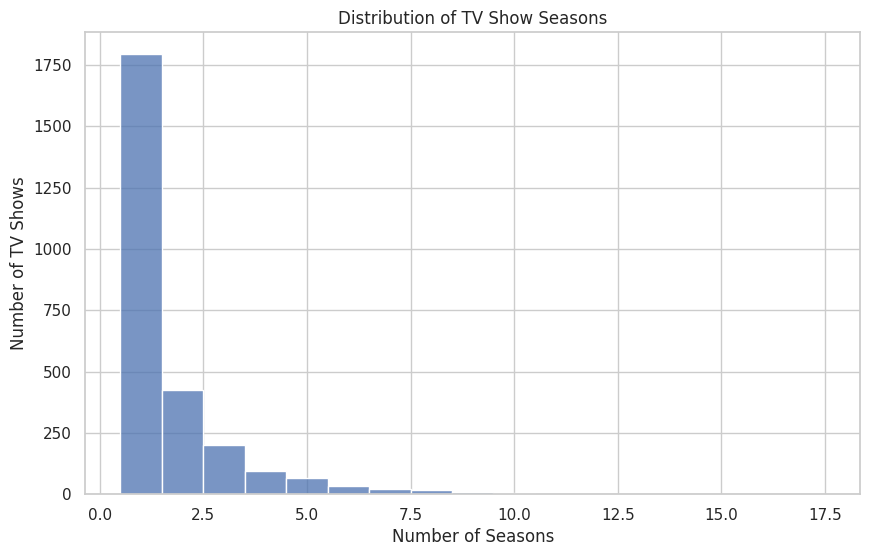

In [ ]:

tv = df[df["type"] == "TV Show"].copy()
tv["seasons"] = pd.to_numeric(
    tv["duration"].str.extract(r"(\d+)")[0], errors="coerce"
)

plt.figure()
sns.histplot(tv["seasons"].dropna(), bins=15, discrete=True)
plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.show()


## Plot 10 – Movie Duration Box Plot
Displays the median, spread and outliers in movie durations.

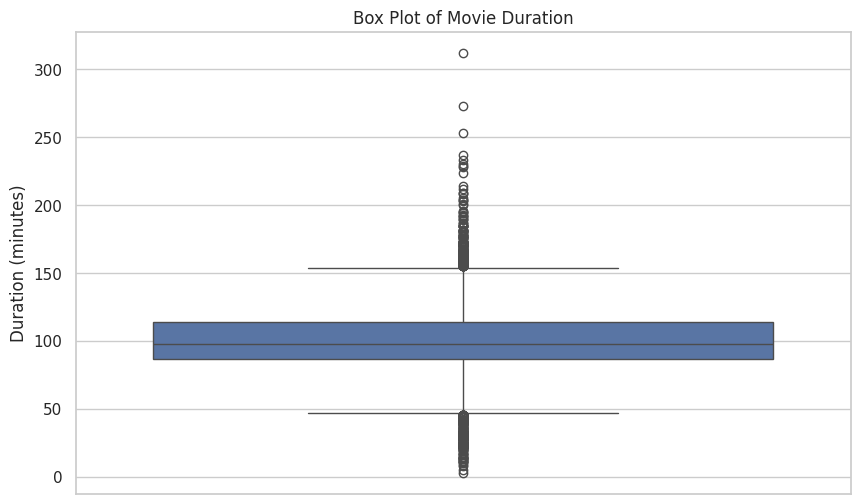

In [ ]:

plt.figure()
sns.boxplot(y=movies["duration_min"].dropna())
plt.title("Box Plot of Movie Duration")
plt.ylabel("Duration (minutes)")
plt.show()


## Plot 11 – Movie Duration Violin Plot
Shows the shape and density of the movie-duration distribution.

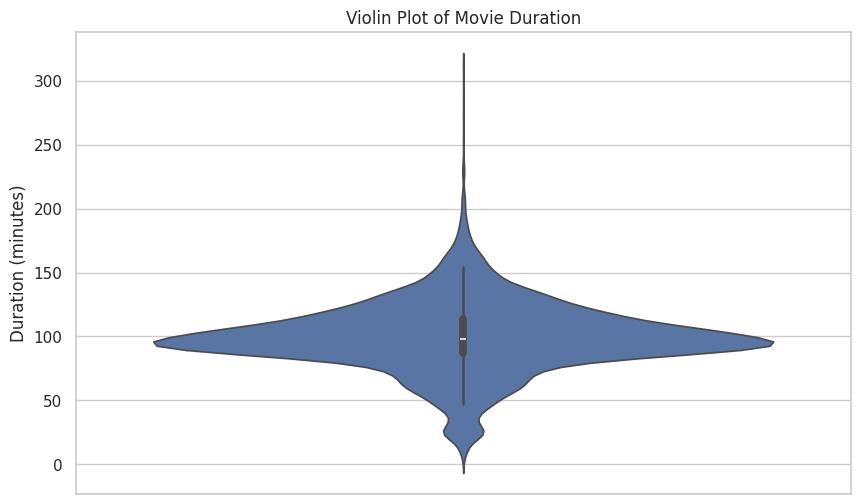

In [ ]:

plt.figure()
sns.violinplot(y=movies["duration_min"].dropna())
plt.title("Violin Plot of Movie Duration")
plt.ylabel("Duration (minutes)")
plt.show()


## Plot 12 – Movie Duration by Rating
Compares movie duration distributions across the most common ratings.

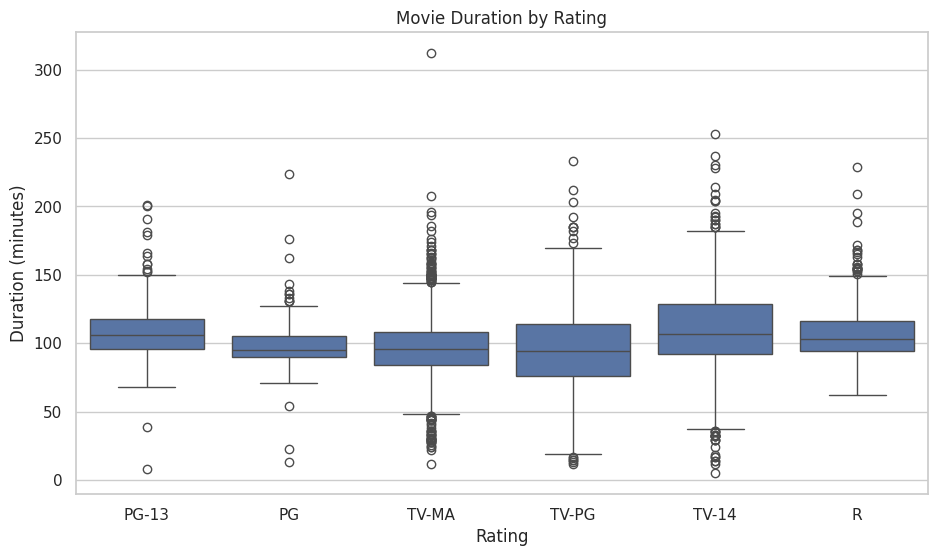

In [ ]:

top_ratings = movies["rating"].value_counts().head(6).index
plot_data = movies[movies["rating"].isin(top_ratings)].dropna(subset=["duration_min"])

plt.figure(figsize=(11, 6))
sns.boxplot(data=plot_data, x="rating", y="duration_min")
plt.title("Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Duration (minutes)")
plt.show()


## Plot 13 – Titles Added to Netflix by Year
Shows the number of titles added to Netflix each year.

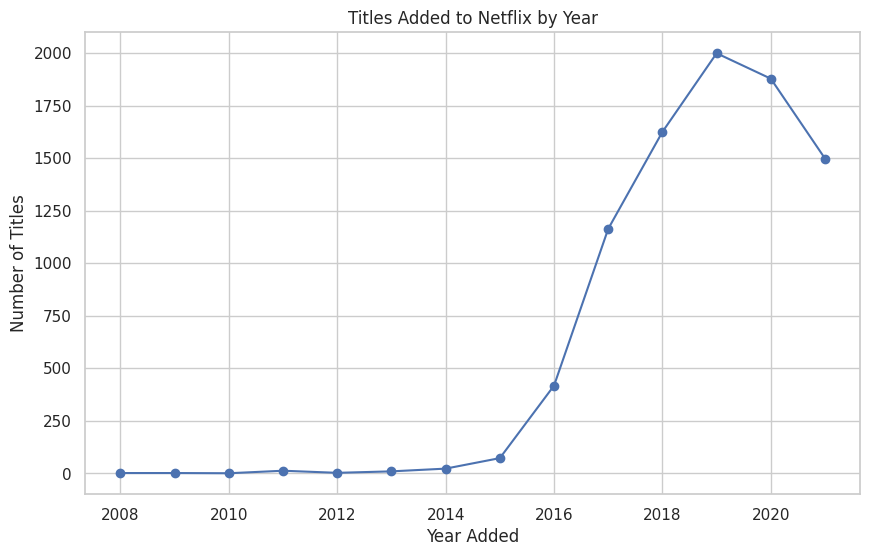

In [ ]:

df["date_added_clean"] = pd.to_datetime(df["date_added"], errors="coerce")
added_by_year = df["date_added_clean"].dt.year.value_counts().sort_index()

plt.figure()
plt.plot(added_by_year.index, added_by_year.values, marker="o")
plt.title("Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


## Plot 14 – Titles Added by Month
Identifies seasonal patterns in when Netflix titles were added.

In [ ]:

month_counts = df["date_added_clean"].dt.month.value_counts().sort_index()

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(11, 6))
sns.barplot(x=[month_names[i-1] for i in month_counts.index],
            y=month_counts.values)
plt.title("Titles Added to Netflix by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()


TypeError: list indices must be integers or slices, not float

<Figure size 1100x600 with 0 Axes>

## Plot 15 – Top 15 Directors
Shows the directors with the highest number of titles in the dataset.

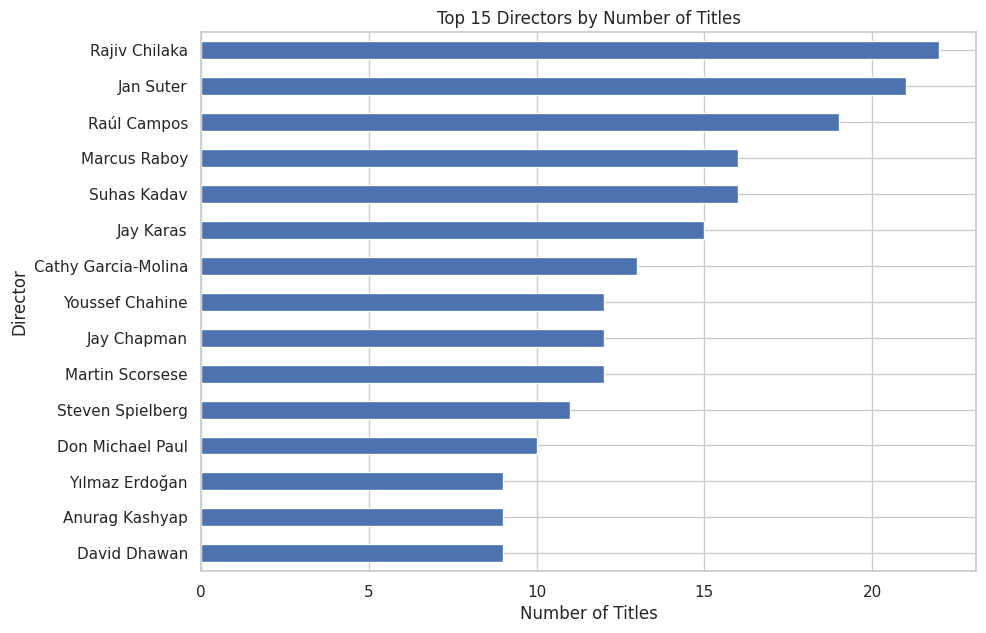

In [ ]:

director_counts = df["director"].dropna().str.split(", ").explode().value_counts().head(15).sort_values()

plt.figure(figsize=(10, 7))
director_counts.plot(kind="barh")
plt.title("Top 15 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()


## Plot 16 – Top 15 Actors
Shows actors who appear most frequently in the dataset.

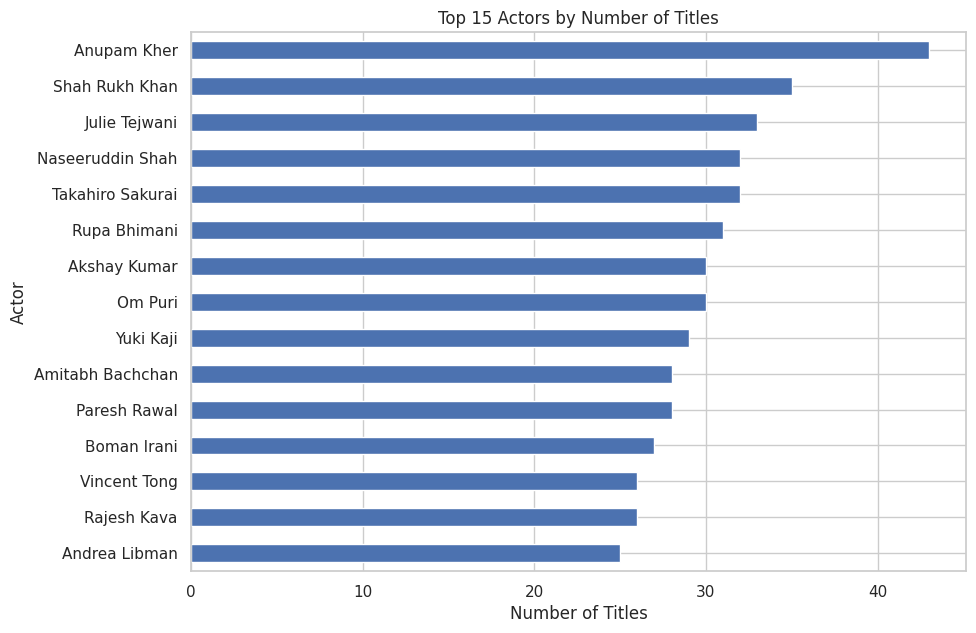

In [ ]:

actor_counts = df["cast"].dropna().str.split(", ").explode().value_counts().head(15).sort_values()

plt.figure(figsize=(10, 7))
actor_counts.plot(kind="barh")
plt.title("Top 15 Actors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()


## Plot 17 – Missing Values by Column
Identifies columns with missing observations and their frequency.

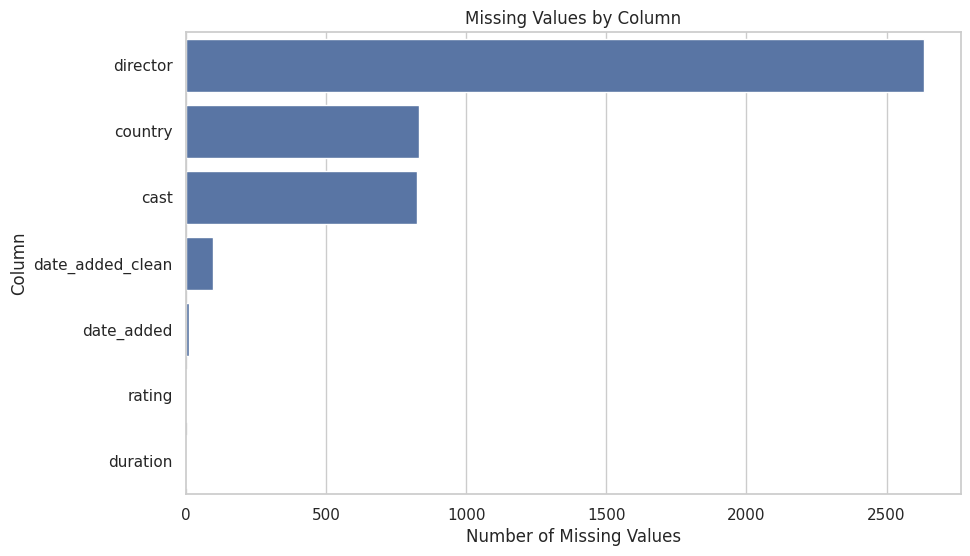

In [ ]:

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.show()


## Plot 18 – Missing Data Heatmap
Provides a visual overview of the location of missing values in the dataset.

In [ ]:

plt.figure(figsize=(12, 7))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


## Plot 19 – Content Type by Rating
Compares how Movie and TV Show content is distributed across ratings.

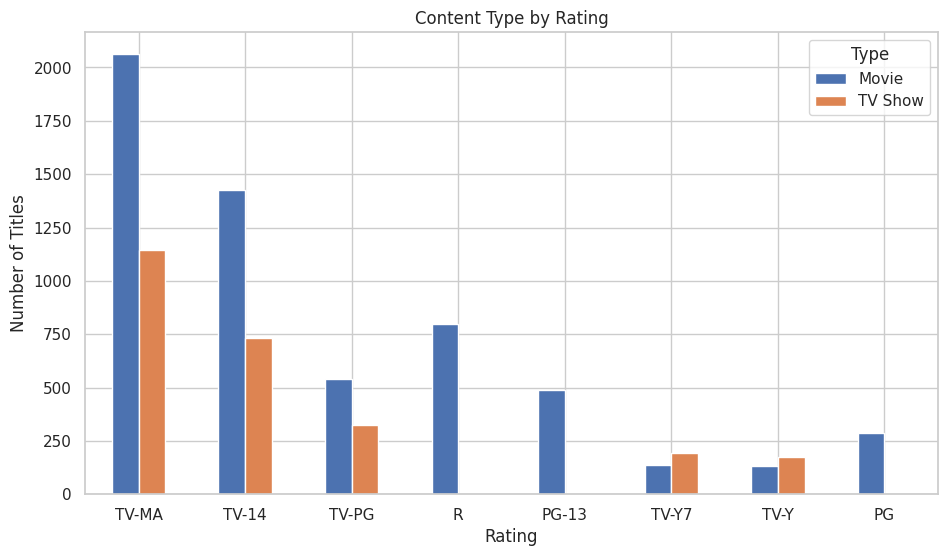

In [ ]:

top_rating_values = df["rating"].value_counts().head(8).index
rating_type = pd.crosstab(df["rating"], df["type"]).loc[top_rating_values]

rating_type.plot(kind="bar", figsize=(11, 6))
plt.title("Content Type by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.legend(title="Type")
plt.show()


## Plot 20 – Heatmap of Rating vs Content Type
Shows the frequency of each content type across ratings using a heatmap.

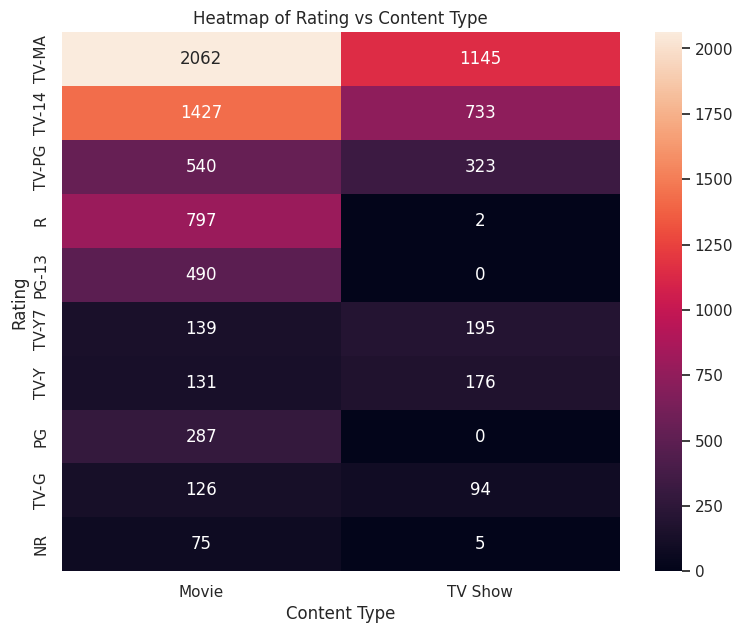

In [ ]:

heat_data = pd.crosstab(df["rating"], df["type"])
heat_data = heat_data.loc[heat_data.sum(axis=1).sort_values(ascending=False).head(10).index]

plt.figure(figsize=(9, 7))
sns.heatmap(heat_data, annot=True, fmt="d")
plt.title("Heatmap of Rating vs Content Type")
plt.xlabel("Content Type")
plt.ylabel("Rating")
plt.show()


## Plot 21 – Top 10 Genres by Content Type
Compares whether popular genres are more strongly associated with Movies or TV Shows.

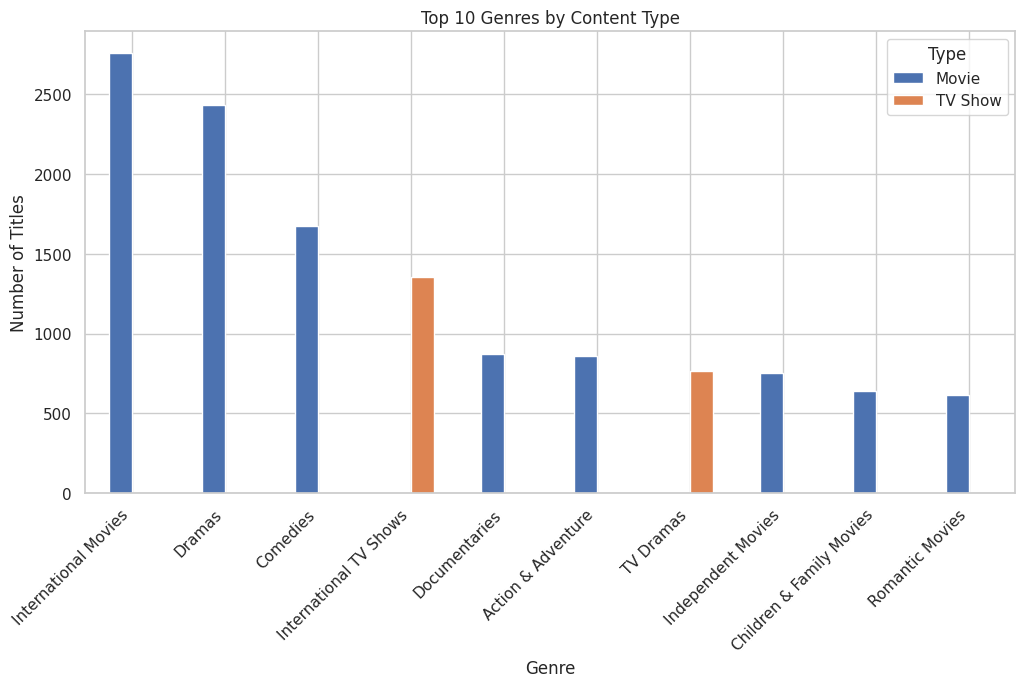

In [ ]:

genre_type = df.copy()
genre_type["genre"] = genre_type["listed_in"].str.split(", ")
genre_type = genre_type.explode("genre")

top_genres = genre_type["genre"].value_counts().head(10).index
genre_type = genre_type[genre_type["genre"].isin(top_genres)]

pivot = pd.crosstab(genre_type["genre"], genre_type["type"])
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Genres by Content Type")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Type")
plt.show()


## Plot 22 – Average Movie Duration by Release Year
Examines how the average movie length has changed over time.

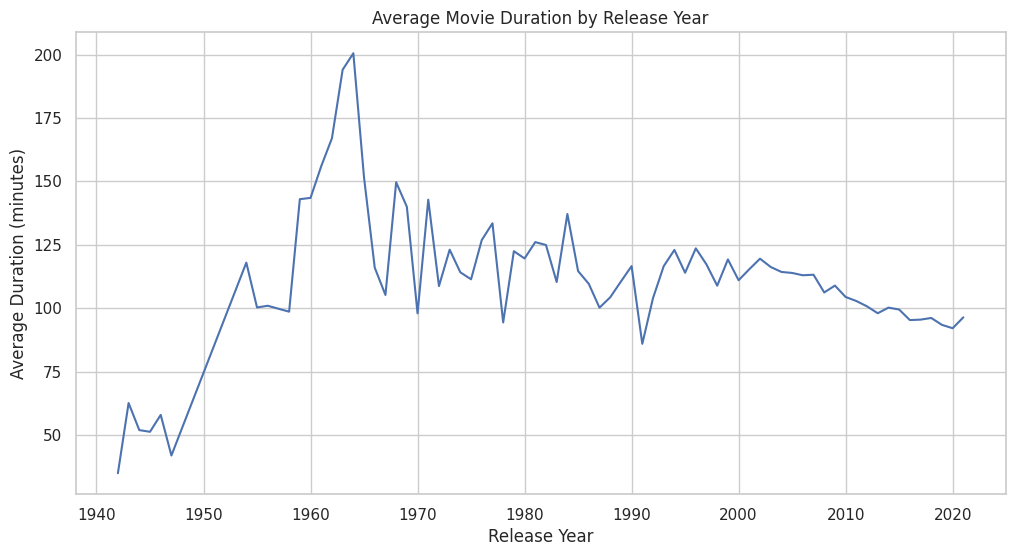

In [ ]:

avg_duration = movies.groupby("release_year")["duration_min"].mean().dropna()

plt.figure(figsize=(12, 6))
plt.plot(avg_duration.index, avg_duration.values)
plt.title("Average Movie Duration by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.show()


## Plot 23 – Number of Titles by Release Decade
Groups release years into decades to reveal long-term trends.

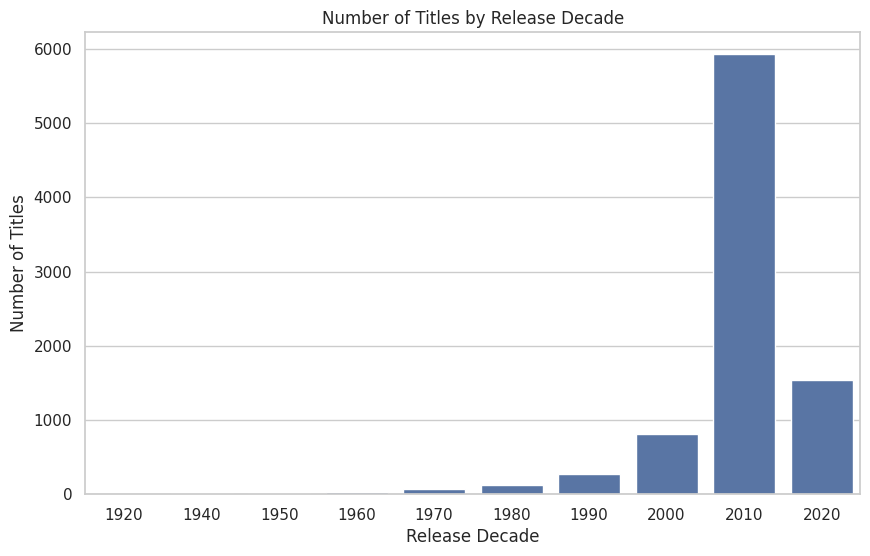

In [ ]:

df["release_decade"] = (df["release_year"] // 10) * 10
decade_counts = df["release_decade"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=decade_counts.index.astype(str), y=decade_counts.values)
plt.title("Number of Titles by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")
plt.show()


## Plot 24 – Top Countries by Content Type
Shows the Movie/TV Show composition of the major content-producing countries.

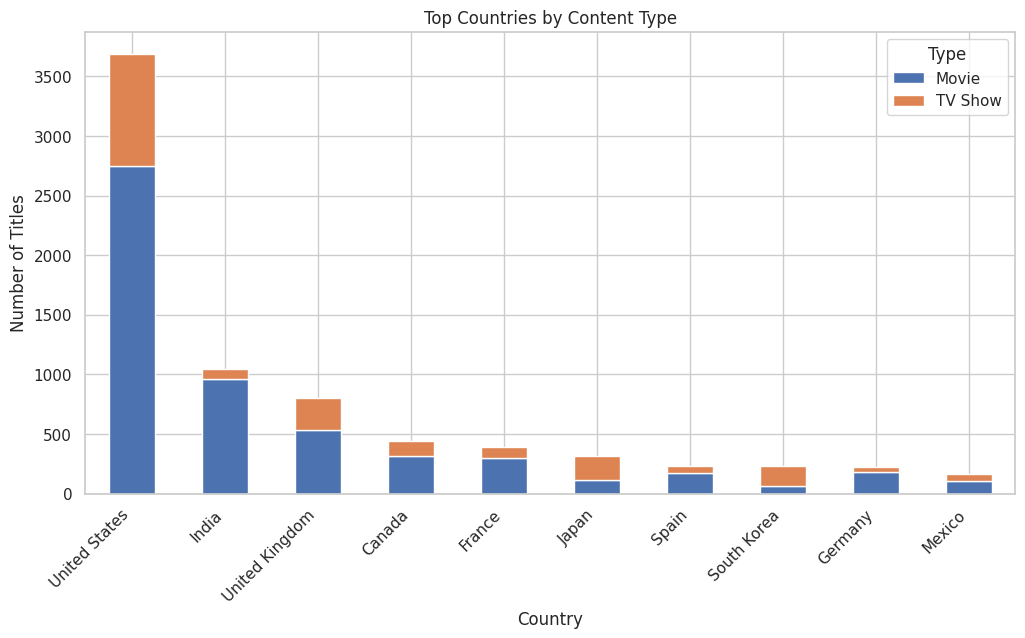

In [ ]:

country_type = df.copy()
country_type["country_single"] = country_type["country"].str.split(", ")
country_type = country_type.explode("country_single")

top_countries = country_type["country_single"].value_counts().head(10).index
country_type = country_type[country_type["country_single"].isin(top_countries)]

ct = pd.crosstab(country_type["country_single"], country_type["type"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

ct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Top Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Type")
plt.show()


## Plot 25 – Release Year vs Movie Duration Scatter Plot
Investigates the relationship between a movie's release year and its duration.

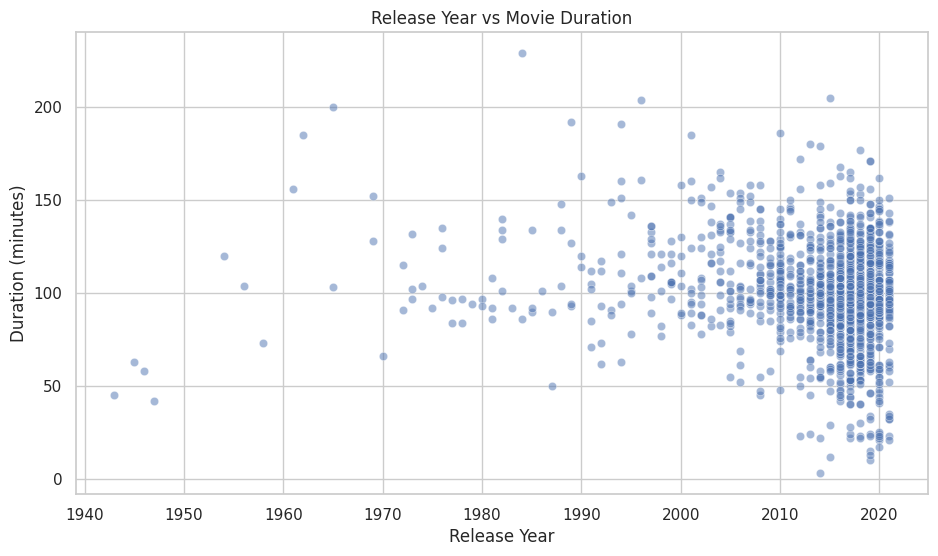

In [ ]:

scatter_data = movies.dropna(subset=["duration_min", "release_year"]).sample(
    min(1500, len(movies)), random_state=42
)

plt.figure(figsize=(11, 6))
sns.scatterplot(data=scatter_data, x="release_year", y="duration_min", alpha=0.5)
plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.show()


## Plot 26 – Number of Movies by Duration Category
Groups movies into short, medium and long-duration categories.

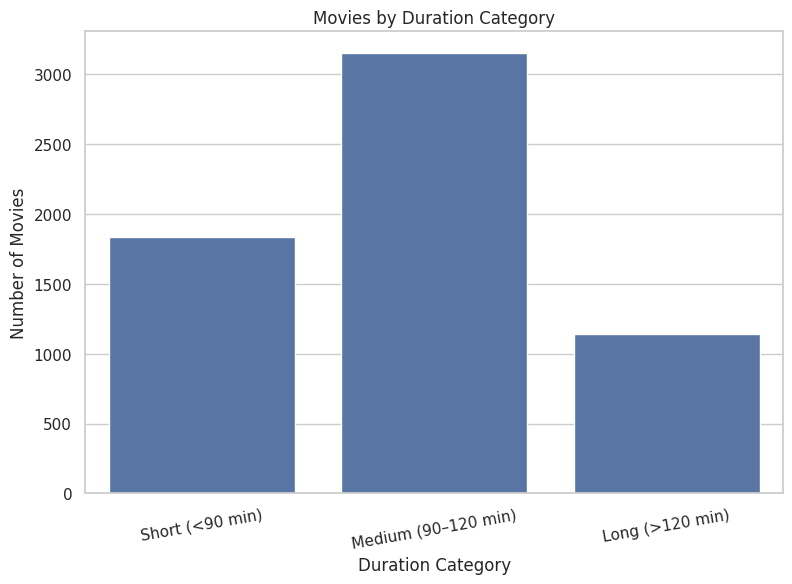

In [ ]:

def duration_category(x):
    if x < 90:
        return "Short (<90 min)"
    elif x <= 120:
        return "Medium (90–120 min)"
    else:
        return "Long (>120 min)"

duration_categories = movies.dropna(subset=["duration_min"]).copy()
duration_categories["duration_category"] = duration_categories["duration_min"].apply(duration_category)

order = ["Short (<90 min)", "Medium (90–120 min)", "Long (>120 min)"]
category_counts = duration_categories["duration_category"].value_counts().reindex(order)

plt.figure(figsize=(9, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title("Movies by Duration Category")
plt.xlabel("Duration Category")
plt.ylabel("Number of Movies")
plt.xticks(rotation=10)
plt.show()


## Plot 27 – TV Shows by Number of Seasons Category
Groups TV Shows according to their number of seasons.

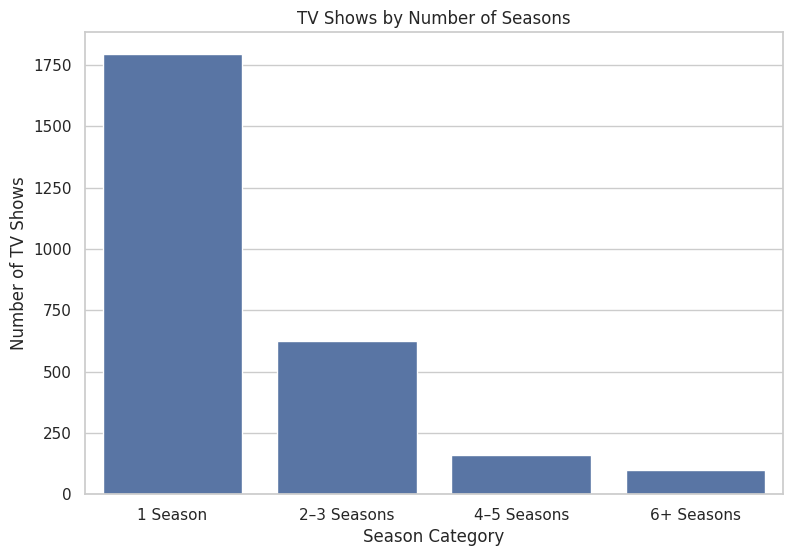

In [ ]:

tv_categories = tv.dropna(subset=["seasons"]).copy()

def season_category(x):
    if x == 1:
        return "1 Season"
    elif x <= 3:
        return "2–3 Seasons"
    elif x <= 5:
        return "4–5 Seasons"
    else:
        return "6+ Seasons"

tv_categories["season_category"] = tv_categories["seasons"].apply(season_category)
order = ["1 Season", "2–3 Seasons", "4–5 Seasons", "6+ Seasons"]
season_counts = tv_categories["season_category"].value_counts().reindex(order)

plt.figure(figsize=(9, 6))
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title("TV Shows by Number of Seasons")
plt.xlabel("Season Category")
plt.ylabel("Number of TV Shows")
plt.show()


## Plot 28 – Top 10 Genres by Average Movie Duration
Compares the average duration of movies across major genres.

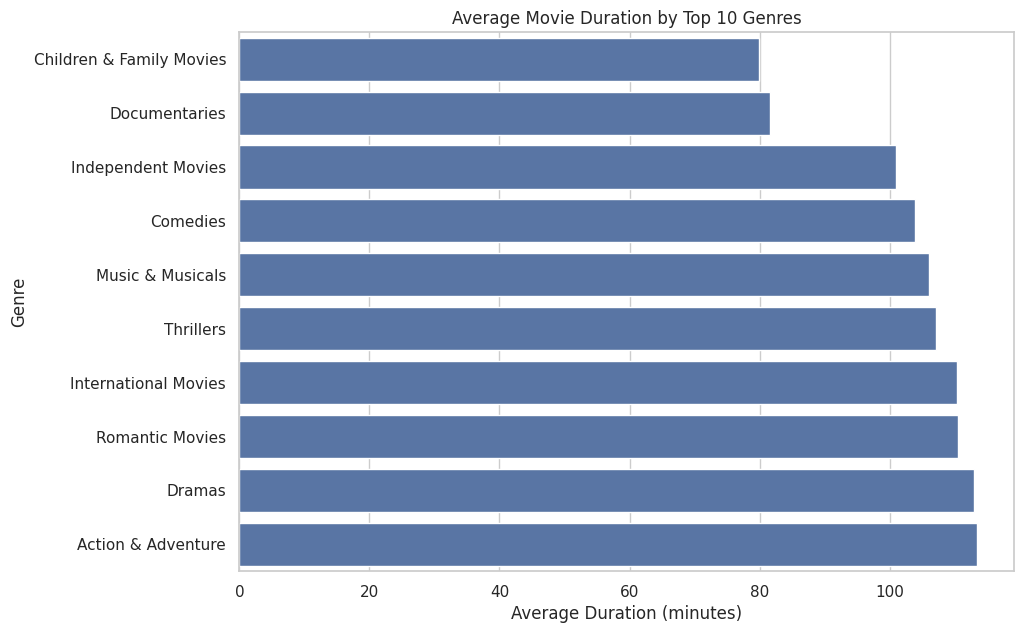

In [ ]:

movie_genres = movies[["listed_in", "duration_min"]].dropna().copy()
movie_genres["genre"] = movie_genres["listed_in"].str.split(", ")
movie_genres = movie_genres.explode("genre")

top_movie_genres = movie_genres["genre"].value_counts().head(10).index
avg_genre_duration = (
    movie_genres[movie_genres["genre"].isin(top_movie_genres)]
    .groupby("genre")["duration_min"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 7))
sns.barplot(x=avg_genre_duration.values, y=avg_genre_duration.index)
plt.title("Average Movie Duration by Top 10 Genres")
plt.xlabel("Average Duration (minutes)")
plt.ylabel("Genre")
plt.show()


## Plot 29 – Titles Added by Year and Content Type
Shows how the addition of Movies and TV Shows to Netflix has changed over time.

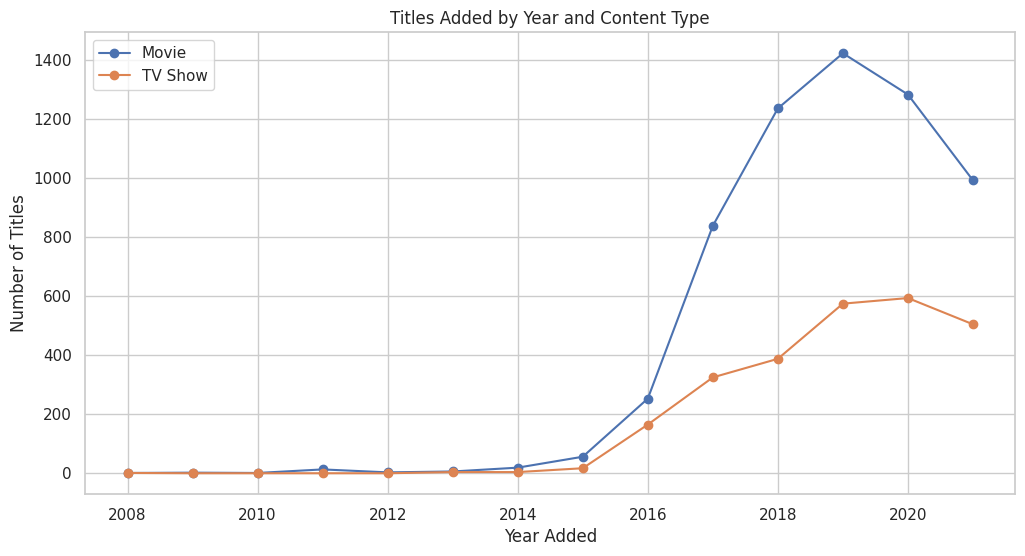

In [ ]:

added_type = (
    df.dropna(subset=["date_added_clean"])
    .assign(added_year=lambda x: x["date_added_clean"].dt.year)
    .groupby(["added_year", "type"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
plt.plot(added_type.index, added_type.get("Movie", 0), marker="o", label="Movie")
plt.plot(added_type.index, added_type.get("TV Show", 0), marker="o", label="TV Show")
plt.title("Titles Added by Year and Content Type")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()


## Plot 30 – Correlation Heatmap of Numerical Variables
Displays correlations among the main numerical variables available after feature extraction.

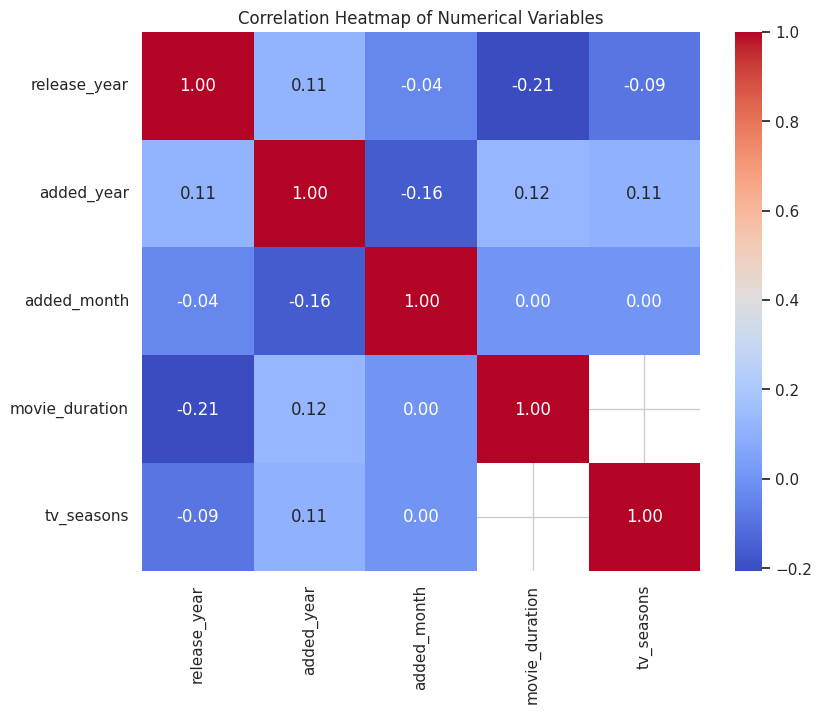

In [ ]:

corr_df = pd.DataFrame({
    "release_year": df["release_year"],
    "added_year": df["date_added_clean"].dt.year,
    "added_month": df["date_added_clean"].dt.month,
    "movie_duration": movies["duration_min"].reindex(df.index),
    "tv_seasons": tv["seasons"].reindex(df.index)
})

plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()
